In [1]:
import matplotlib.pyplot as plt
import os
from PIL import Image
import json
import numpy as np
from IPython.display import Markdown, display

from isofit.core.forward import ForwardModel
from isofit.core.fileio import IO
from isofit.inversion.inverse import Inversion
from isofit.configs import configs
from isofit.data import env

### Front matter
We select an output directory that has previously had apply_oe run on it, just for convenience.  A configuration could also be written from scratch.

In [2]:
tutorial_path = "/Users/brodrick/repos/isofit/EARSEL/EARSeL_ISOFIT_Tutorial"
fid = "ENMAP01-____L1C-DT0000025905_20230707T192008Z_001_V010303_20230922T131737Z"
name = "Nevada"
output = f"{tutorial_path}/medium_example/{name}"

## Open and display the configuration file

All components that are in brackets {} will be replaced - the json.tmpl file is built for system transferability. 

In [3]:
config_file = f'{output}/config/{fid.split("_")[-4]}_isofit.json.tmpl'
with open(config_file) as f:
    display(Markdown(f"```json\n{json.dumps(json.load(f), indent=4)}\n```"))

```json
{
    "forward_model": {
        "atmosphere": {
            "engine": {
                "aerosol_template_file": "{env.data}/aerosol_template.json",
                "earth_sun_distance_file": "{env.data}/earth_sun_distance.txt",
                "emulator_aux_file": "{env.srtmnet}/sRTMnet_v120_aux.npz",
                "emulator_file": "{env.srtmnet}/sRTMnet_v120.h5",
                "engine_base_dir": "{env.sixs}",
                "engine_name": "sRTMnet",
                "irradiance_file": "{env.examples}/20151026_SantaMonica/data/prism_optimized_irr.dat",
                "lut_names": {
                    "AOT550": null,
                    "H2OSTR": null
                },
                "lut_path": "{working_directory}/lut_full/lut.nc",
                "multipart_transmittance": false,
                "sim_path": "{working_directory}/lut_full",
                "statevector_names": [
                    "H2OSTR",
                    "AOT550"
                ],
                "template_file": "{working_directory}/config/20230707T192008Z_modtran_tpl.json"
            },
            "lut_grid": {
                "AOT550": [
                    0.04209,
                    0.137881,
                    0.233672,
                    0.329463,
                    0.425254,
                    0.521045,
                    0.6168359999999999,
                    0.712627,
                    0.808418,
                    0.9042089999999999,
                    1.0
                ],
                "H2OSTR": [
                    0.7275000214576721,
                    0.8744000196456909,
                    1.021299958229065
                ]
            },
            "statevector": {
                "AOT550": {
                    "bounds": [
                        0.04209,
                        1.0
                    ],
                    "init": 0.137881,
                    "prior_mean": 0.137881,
                    "prior_sigma": 10.0,
                    "scale": 1
                },
                "H2OSTR": {
                    "bounds": [
                        0.7275000214576721,
                        1.021299958229065
                    ],
                    "init": 0.8743999898433685,
                    "prior_mean": 0.8743999898433685,
                    "prior_sigma": 100.0,
                    "scale": 1
                }
            },
            "unknowns": {
                "H2O_ABSCO": 0.0
            }
        },
        "instrument": {
            "SNR": 500,
            "integrations": 50,
            "unknowns": {
                "dn_uncertainty_file": null,
                "uncorrelated_radiometric_uncertainty": 0.01
            },
            "wavelength_file": "{working_directory}/data/wavelengths.txt"
        },
        "surface": {
            "max_slope": 20.0,
            "multi_surface_flag": false,
            "surface_category": "multicomponent_surface",
            "surface_file": "{working_directory}/data/surface.mat",
            "terrain_style": "dem"
        }
    },
    "implementation": {
        "debug_mode": false,
        "inversion": {
            "windows": [
                [
                    350.0,
                    1360.0
                ],
                [
                    1410,
                    1800.0
                ],
                [
                    1970.0,
                    2500.0
                ]
            ]
        },
        "isofit_version": "4.0.0-alpha",
        "n_cores": 10,
        "ray_address": null,
        "ray_temp_dir": "/tmp/ray"
    },
    "input": {
        "loc_file": "{working_directory}/input/20230707T192008Z_subs_loc",
        "measured_radiance_file": "{working_directory}/input/20230707T192008Z_subs_rdn",
        "obs_file": "{working_directory}/input/20230707T192008Z_subs_obs"
    },
    "output": {
        "estimated_reflectance_file": "{working_directory}/output/20230707T192008Z_subs_rfl",
        "estimated_state_file": "{working_directory}/output/20230707T192008Z_subs_state",
        "posterior_uncertainty_file": "{working_directory}/output/20230707T192008Z_subs_uncert"
    }
}
```

## Convert the template configuration file

In [4]:
resolved_config_file = env.fromTemplate(config_file, working_directory=output)
config = configs.create_new_config(resolved_config_file)
with open(resolved_config_file) as f:
    display(Markdown(f"```json\n{json.dumps(json.load(f), indent=4)}\n```"))

```json
{
    "forward_model": {
        "atmosphere": {
            "engine": {
                "aerosol_template_file": "/Users/bohn/Desktop/JPL_ISOFIT_Project/test_data/data/aerosol_template.json",
                "earth_sun_distance_file": "/Users/bohn/Desktop/JPL_ISOFIT_Project/test_data/data/earth_sun_distance.txt",
                "emulator_aux_file": "/Users/bohn/Desktop/sRTMnet/sRTMnet_v120_aux.npz",
                "emulator_file": "/Users/bohn/Desktop/sRTMnet/sRTMnet_v120.h5",
                "engine_base_dir": "/Users/bohn/Desktop/6sV2.1_4c",
                "engine_name": "sRTMnet",
                "irradiance_file": "/Users/bohn/Desktop/JPL_ISOFIT_Project/test_data/examples/20151026_SantaMonica/data/prism_optimized_irr.dat",
                "lut_names": {
                    "AOT550": null,
                    "H2OSTR": null
                },
                "lut_path": "/Users/bohn/Desktop/Conferences/EARSeL_2026/Tutorial/EARSeL_ISOFIT_tutorial//medium_example/Nevada/lut_full/lut.nc",
                "multipart_transmittance": false,
                "sim_path": "/Users/bohn/Desktop/Conferences/EARSeL_2026/Tutorial/EARSeL_ISOFIT_tutorial//medium_example/Nevada/lut_full",
                "statevector_names": [
                    "H2OSTR",
                    "AOT550"
                ],
                "template_file": "/Users/bohn/Desktop/Conferences/EARSeL_2026/Tutorial/EARSeL_ISOFIT_tutorial//medium_example/Nevada/config/20230707T192008Z_modtran_tpl.json"
            },
            "lut_grid": {
                "AOT550": [
                    0.04209,
                    0.137881,
                    0.233672,
                    0.329463,
                    0.425254,
                    0.521045,
                    0.6168359999999999,
                    0.712627,
                    0.808418,
                    0.9042089999999999,
                    1.0
                ],
                "H2OSTR": [
                    0.7275000214576721,
                    0.8744000196456909,
                    1.021299958229065
                ]
            },
            "statevector": {
                "AOT550": {
                    "bounds": [
                        0.04209,
                        1.0
                    ],
                    "init": 0.137881,
                    "prior_mean": 0.137881,
                    "prior_sigma": 10.0,
                    "scale": 1
                },
                "H2OSTR": {
                    "bounds": [
                        0.7275000214576721,
                        1.021299958229065
                    ],
                    "init": 0.8743999898433685,
                    "prior_mean": 0.8743999898433685,
                    "prior_sigma": 100.0,
                    "scale": 1
                }
            },
            "unknowns": {
                "H2O_ABSCO": 0.0
            }
        },
        "instrument": {
            "SNR": 500,
            "integrations": 50,
            "unknowns": {
                "dn_uncertainty_file": null,
                "uncorrelated_radiometric_uncertainty": 0.01
            },
            "wavelength_file": "/Users/bohn/Desktop/Conferences/EARSeL_2026/Tutorial/EARSeL_ISOFIT_tutorial//medium_example/Nevada/data/wavelengths.txt"
        },
        "surface": {
            "max_slope": 20.0,
            "multi_surface_flag": false,
            "surface_category": "multicomponent_surface",
            "surface_file": "/Users/bohn/Desktop/Conferences/EARSeL_2026/Tutorial/EARSeL_ISOFIT_tutorial//medium_example/Nevada/data/surface.mat",
            "terrain_style": "dem"
        }
    },
    "implementation": {
        "debug_mode": false,
        "inversion": {
            "windows": [
                [
                    350.0,
                    1360.0
                ],
                [
                    1410,
                    1800.0
                ],
                [
                    1970.0,
                    2500.0
                ]
            ]
        },
        "isofit_version": "4.0.0-alpha",
        "n_cores": 10,
        "ray_address": null,
        "ray_temp_dir": "/tmp/ray"
    },
    "input": {
        "loc_file": "/Users/bohn/Desktop/Conferences/EARSeL_2026/Tutorial/EARSeL_ISOFIT_tutorial//medium_example/Nevada/input/20230707T192008Z_subs_loc",
        "measured_radiance_file": "/Users/bohn/Desktop/Conferences/EARSeL_2026/Tutorial/EARSeL_ISOFIT_tutorial//medium_example/Nevada/input/20230707T192008Z_subs_rdn",
        "obs_file": "/Users/bohn/Desktop/Conferences/EARSeL_2026/Tutorial/EARSeL_ISOFIT_tutorial//medium_example/Nevada/input/20230707T192008Z_subs_obs"
    },
    "output": {
        "estimated_reflectance_file": "/Users/bohn/Desktop/Conferences/EARSeL_2026/Tutorial/EARSeL_ISOFIT_tutorial//medium_example/Nevada/output/20230707T192008Z_subs_rfl",
        "estimated_state_file": "/Users/bohn/Desktop/Conferences/EARSeL_2026/Tutorial/EARSeL_ISOFIT_tutorial//medium_example/Nevada/output/20230707T192008Z_subs_state",
        "posterior_uncertainty_file": "/Users/bohn/Desktop/Conferences/EARSeL_2026/Tutorial/EARSeL_ISOFIT_tutorial//medium_example/Nevada/output/20230707T192008Z_subs_uncert"
    }
}
```

## Initialize core isofit components

```python
class ForwardModel(
    full_config: Any,
    cache_atmosphere: Atmosphere = None
)
```
`ForwardModel` contains all the information about how to calculate radiance measurements at a specific spectral calibration, given a state vector. It also manages the distributions of unretrieved, unknown parameters of the state vector (i.e. the S_b and K_b matrices of Rodgers et al.

State vector elements always go in the following order:

(1) Surface parameters
(2) Atmospheric Radiative Transfer parameters
(3) Instrument parameters

The parameter bounds, scales, initial values, and names are all ordered in this way. The variable self.statevec contains the name of each state vector element, in the proper ordering.

The "b" vector corresponds to the K_b calculations in Rogers (2000); the variables bvec and bval represent the model unknowns' names and their magnitudes, respectively. Larger magnitudes correspond to a larger variance in the unknown values. This acts as additional noise for the purpose of weighting the measurement information against the prior.

In [5]:
fm = ForwardModel(config)
io = IO(config, fm)

/Users/bohn/mambaforge/envs/isofit_test_env/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/bohn/mambaforge/envs/isofit_test_env/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/bohn/mambaforge/envs/isofit_test_env/lib/python3.13/site-packages/isofit/atmosphere/atmosphere.py:549: FutureWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'point'} to avoid an error in the future.
  ds[term] = ds[key1] * ds[key2]


## Load data from a point

```python
io.get_components_at_index(row: int, col: int) -> InputData
```

Load data from input files at the specified `(row, col)` index.

| Parameter | Type | Description |
|-----------|------|-------------|
| `row` | `int` | Row index to retrieve data from |
| `col` | `int` | Column index to retrieve data from |

**Returns:** `InputData` — object containing all current data reads


### Key points

- The input data from this configuration file points to a file which has already been run through a superpixel aggregation, and is in a special format - more on that in coming tutorials
- The 0th row is null in this form, and there is only one column


In [6]:
dat = io.get_components_at_index(10, 0)
dat.__dict__.keys()

dict_keys(['meas', 'geom', 'reference_reflectance'])

## Let's unpack the geometry object:

In [7]:
for key, val in dat.geom.__dict__.items():
    if type(val) != np.ndarray:
        display(Markdown(f"```\n{key}: {val}\n```"))

```
observer_zenith: 12.916895530800009
```

```
observer_azimuth: 13.095659021999989
```

```
solar_zenith: 16.64164200000002
```

```
solar_azimuth: 152.00715599999987
```

```
observer_altitude_km: 632.120033153366
```

...

```
longitude: -117.16448343857272
```

```
use_universal_coszen: True
```

```
lut_grid: OrderedDict({'AOT550': [0.04209, 0.137881, 0.233672, 0.329463, 0.425254, 0.521045, 0.6168359999999999, 0.712627, 0.808418, 0.9042089999999999, 1.0], 'H2OSTR': [0.7275000214576721, 0.8744000196456909, 1.021299958229065]})
```

```
coszen: 0.95811468592849
```

```
min_cosi: 0.8023839329145401
```

## And show the radiance

<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
/var/folders/26/342qx1c175scf02ss06xrrgr0000gq/T/ipykernel_6895/3268142096.py:4: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Radiance [$\mu$W sr$^{-1}$ cm$^{-2}$ nm$^{-1}$]')


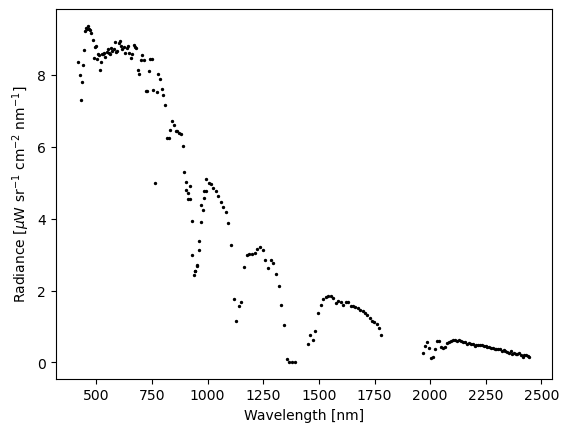

In [8]:
plt.figure()
plt.scatter(io.meas_wl, dat.meas, c='black', s=2)
plt.xlabel('Wavelength [nm]')
plt.ylabel('Radiance [$\mu$W sr$^{-1}$ cm$^{-2}$ nm$^{-1}$]')
plt.show()

## Let's refresh what the lut grid looks like, and grab some atmospheric parameters

There are three main atmospheric parameters here:
- Atmospheric Path Reflectance
- Spherical Sky Albedo
- Transmittance (stored in Downward Diffuse Transmittance for the 3c case)

In [9]:
fm.atmosphere.lut_grid

OrderedDict([('AOT550',
              [0.04209,
               0.137881,
               0.233672,
               0.329463,
               0.425254,
               0.521045,
               0.6168359999999999,
               0.712627,
               0.808418,
               0.9042089999999999,
               1.0]),
             ('H2OSTR',
              [0.7275000214576721, 0.8744000196456909, 1.021299958229065])])

In [10]:
rho, L_tot, L_dir_dir, L_dif_dir, L_dir_dif, L_dif_dif, = fm.calc_atmosphere_quantities([0.05, 0.88], dat.geom)

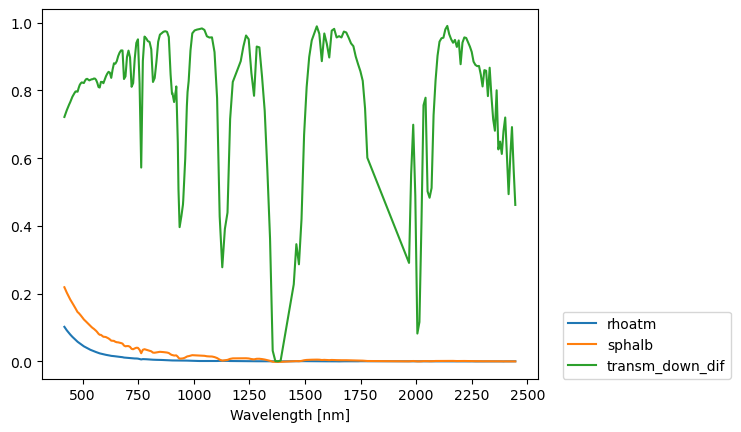

In [11]:
plt.figure()
for key, val in rho.items():
    if type(val) != np.float64:
        plt.plot(io.meas_wl, val, label=key)
plt.xlabel('Wavelength [nm]')
plt.legend(loc=(1.05, 0))
plt.show()

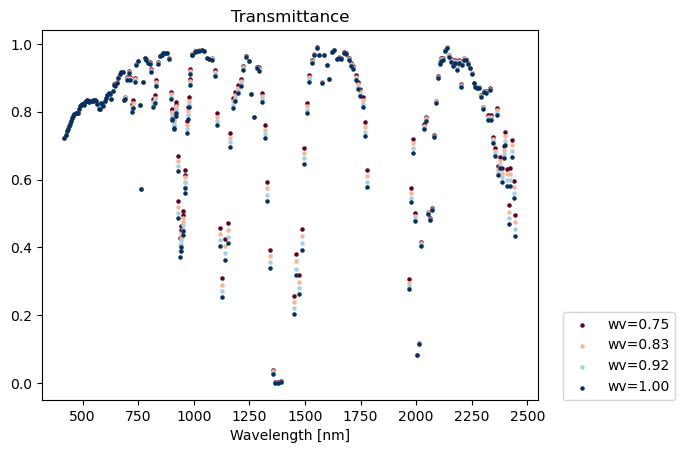

In [12]:
wv_range = np.linspace(0.75,1, 4)
cmap = plt.cm.RdBu
colors = [cmap(i / (len(wv_range) - 1)) for i in range(len(wv_range))]

plt.figure()
for i, wv in enumerate(wv_range):
    rho_wv, L_tot, L_dir_dir, L_dif_dir, L_dir_dif, L_dif_dif, = fm.calc_atmosphere_quantities([0.05, wv], dat.geom)
    plt.scatter(io.meas_wl, rho_wv['transm_down_dif'], s=5, color=colors[i], label=f'wv={wv:.2f}')
plt.xlabel('Wavelength [nm]')
plt.title('Transmittance')
plt.legend(loc=(1.05, 0))
plt.show()

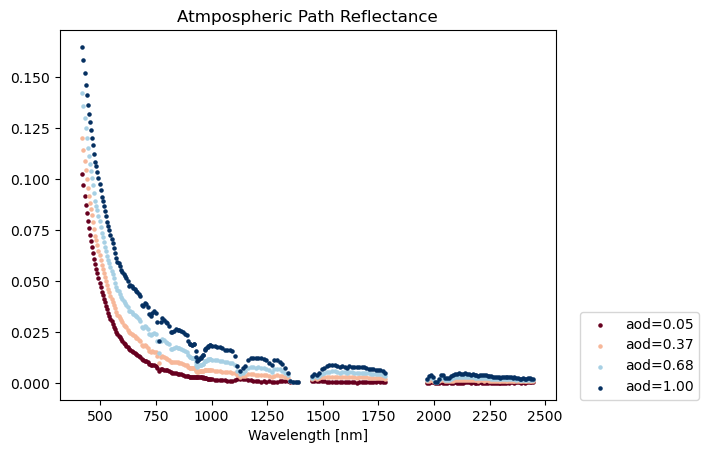

In [13]:
aod_range = np.linspace(0.05,1, 4)

plt.figure()
for i, aod in enumerate(aod_range):
    rho_wv, L_tot, L_dir_dir, L_dif_dir, L_dir_dif, L_dif_dif, = fm.calc_atmosphere_quantities([aod, 0.88], dat.geom)
    plt.scatter(io.meas_wl, rho_wv['rhoatm'], s=5, color=colors[i], label=f'aod={aod:.2f}')
plt.xlabel('Wavelength [nm]')
plt.title('Atmpospheric Path Reflectance')
plt.legend(loc=(1.05, 0))
plt.show()

## Now let's look at how to model at-sensor radiance from a given state vector

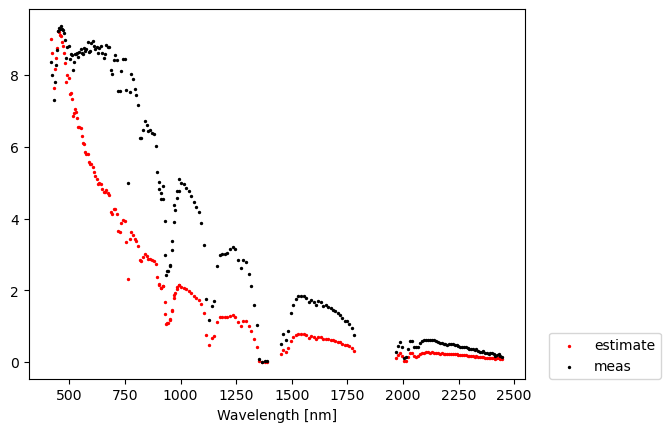

In [14]:
x = np.zeros(len(fm.statevec))
x[fm.idx_atmosphere] = np.array([0.05, 0.88])
x[fm.idx_surf_rfl] = 0.1
est_rdn = fm.calc_meas(x, dat.geom)

plt.figure()
plt.scatter(io.meas_wl, est_rdn, c='red', s=2, label='estimate')
plt.scatter(io.meas_wl, dat.meas, c='black', s=2, label='meas')
plt.xlabel('Wavelength [nm]')
plt.legend(loc=(1.05, 0))
plt.show()

## Similar to above, we can sweep atmospheric states

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
/var/folders/26/342qx1c175scf02ss06xrrgr0000gq/T/ipykernel_6895/1981892335.py:12: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Radiance [$\mu$W sr$^{-1}$ cm$^{-2}$ nm$^{-1}$]')
/var/folders/26/342qx1c175scf02ss06xrrgr0000gq/T/ipykernel_6895/1981892335.py:23: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Radiance [$\mu$W sr$^{-1}$ cm$^{-2}$ nm$^{-1}$]')


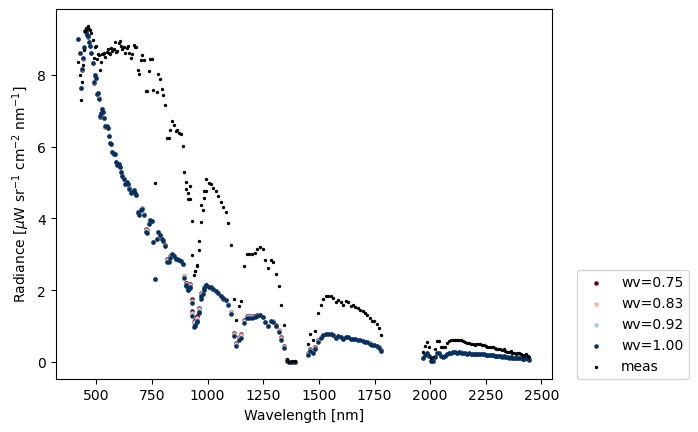

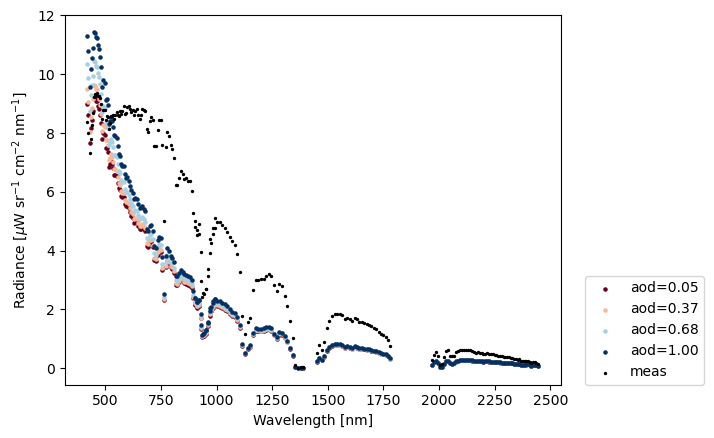

In [15]:
x = np.zeros(len(fm.statevec))
x[fm.idx_surf_rfl] = 0.1

plt.figure()
for i, wv in enumerate(wv_range):
    x[fm.idx_atmosphere] = np.array([0.05, wv])
    est_rdn = fm.calc_meas(x, dat.geom)
    plt.scatter(io.meas_wl, est_rdn, s=5, color=colors[i], label=f'wv={wv:.2f}')
plt.scatter(io.meas_wl, dat.meas, c='black', s=2, label='meas')

plt.xlabel('Wavelength [nm]')
plt.ylabel('Radiance [$\mu$W sr$^{-1}$ cm$^{-2}$ nm$^{-1}$]')
plt.legend(loc=(1.05, 0))
plt.show()

plt.figure()
for i, aod in enumerate(aod_range):
    x[fm.idx_atmosphere] = np.array([aod, 0.88])
    est_rdn = fm.calc_meas(x, dat.geom)
    plt.scatter(io.meas_wl, est_rdn, s=5, color=colors[i], label=f'aod={aod:.2f}')
plt.scatter(io.meas_wl, dat.meas, c='black', s=2, label='meas')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Radiance [$\mu$W sr$^{-1}$ cm$^{-2}$ nm$^{-1}$]')
plt.legend(loc=(1.05, 0))
plt.show()

## And of course, we can look at the impact of reflectance as well

<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
/var/folders/26/342qx1c175scf02ss06xrrgr0000gq/T/ipykernel_6895/3280196068.py:10: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Radiance [$\mu$W sr$^{-1}$ cm$^{-2}$ nm$^{-1}$]')


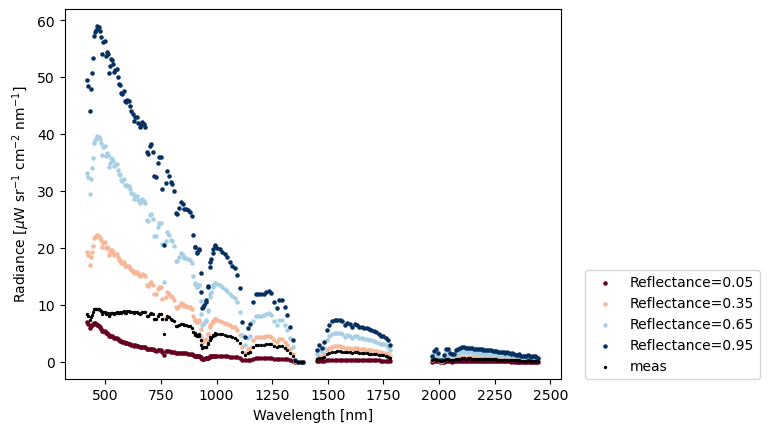

In [16]:
x[fm.idx_atmosphere] = np.array([0.05, 0.88])
surface_range = np.linspace(0.05, 0.95, 4)
plt.figure()
for i, surf in enumerate(surface_range):
    x[fm.idx_surface] = surf
    est_rdn = fm.calc_meas(x, dat.geom)
    plt.scatter(io.meas_wl, est_rdn, s=5, color=colors[i], label=f'Reflectance={surf:.2f}')
plt.scatter(io.meas_wl, dat.meas, c='black', s=2, label='meas')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Radiance [$\mu$W sr$^{-1}$ cm$^{-2}$ nm$^{-1}$]')
plt.legend(loc=(1.05, 0))
plt.show()